In [1]:
%load_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import pandas as pd

import model


def table(frame, caption, precision=3):
    """Render a table with a caption above it, the way a paper labels one."""
    frame = frame.to_frame() if isinstance(frame, pd.Series) else frame
    return frame.style.set_caption(caption).format(precision=precision)

# World Cup Poisson model

Goals scored by each side are modelled as independent Poisson counts with a log link:

$$\log \lambda_{ij} = \mu + \alpha_i - \delta_j + h \cdot \mathbb{1}[\text{not neutral}]$$

Two parameters per team, attack $\alpha$ and defence $\delta$, plus a global intercept and a
home advantage term, fitted by Poisson regression with a ridge penalty. The outer product of
the two marginal goal distributions gives a scoreline grid, and summing its lower triangle,
diagonal and upper triangle gives the 1X2 probabilities.

The notebook builds that up in order: fit, score against a baseline, add time decay, then
the Dixon Coles correction for draws. Each section keeps whatever the previous one
established. With the settings frozen it refits at the 2026 cutoff, scores the tournament
once, simulates the knockout bracket, and ends by asking what the model would have said on
the morning of the final.

All date filtering is confined to `model.split`, which `model.fit` calls internally, so cell
execution order cannot leak post cutoff results into a fit.

## The data

International results from 2000, restricted to the 211 FIFA member associations. Membership
is derived from the data rather than a list: playing a qualifier or a World Cup is what it
means in practice. That drops regions, territories, unrecognised states and diaspora sides,
none of which can reach a World Cup, and takes the intercept down with it, since a slice of
the old goal rate was blowouts against sides that were never really international.

Historic names are folded into current ones first, so a team keeps one coefficient across a
rename rather than splitting its history.

Matches are not weighted by competitive relevance. They were, and sweeping it showed the
assumption backwards: the more weight friendlies got the better the fit scored, on World Cup
matches as much as overall, while the World Cup weight itself did nothing. Qualifying is
regional, so friendlies are where confederations actually meet, and they carry most of the
evidence tying one continent's scale to another's. The tags survive only to stratify the
scores at the end.

In [2]:
df = model.load()
print(f"{len(df)} matches, {df.date.min().date()} -> {df.date.max().date()}")
table(df.WC_tag.value_counts().rename_axis("match type").rename("matches"),
      "Table 1. Matches available after filtering, counted by type.")

23933 matches, 2000-01-04 -> 2026-07-19


,matches
match type,
OTHER,9400
Friendly,8148
FIFA,5897
World Cup,488


In [3]:
print(f"teams: {pd.unique(df[['home_team', 'away_team']].values.ravel()).size}")
print(f"distinct matchups: {pd.DataFrame(np.sort(df[['home_team', 'away_team']].values, 1)).drop_duplicates().shape[0]}")

teams: 211
distinct matchups: 5785


## Train and tuning split

Cutoff at the 2022 opening fixture. The tuning set is every match in the inter tournament
window, not just the 64 World Cup fixtures, which is two orders of magnitude more data to
tune against.

`end=CUTOFF_2026` leaves 2026 out of both halves. It is the final test.

In [4]:
train, holdout = model.split(df, model.CUTOFF_2022, model.CUTOFF_2026)
print(f"train:   {len(train)} matches, up to {train.date.max().date()}")
print(f"holdout: {len(holdout)} matches, {holdout.date.min().date()} -> {holdout.date.max().date()}")
table(holdout.WC_tag.value_counts().rename_axis("match type").rename("matches"),
      "Table 2. The tuning holdout, counted by match type.")

train:   20316 matches, up to 2022-11-19
holdout: 3513 matches, 2022-11-20 -> 2026-06-10


,matches
match type,
OTHER,1554
FIFA,958
Friendly,937
World Cup,64


## Fitting

Nothing dated 2022-11-20 or later is visible to this fit.

`exp(intercept)` is the goal rate for a fixture between two average teams on neutral ground.
`exp(home_adv)` is the multiplicative home effect.

In [5]:
params = model.fit(df, model.CUTOFF_2022)

print(f"baseline goal rate  {np.exp(params.intercept):.2f} per team per match")
print(f"home advantage      x{np.exp(params.home_adv):.2f} when not on neutral ground")

baseline goal rate  1.05 per team per match
home advantage      x1.36 when not on neutral ground


Defence columns are negated in the design matrix, so both coefficients run higher is better
and their sum is a crude single rating. They are on the log scale and identified only up to
the intercept, so read them relatively.

In [6]:
table(model.strength(params).head(10),
      "Table 3. Strongest teams at the 2022 cutoff. Attack and defence on the log scale, higher is better.")

log scale,attack,defence,total
team,,,
Brazil,1.332,1.358,2.690
Spain,1.192,1.244,2.436
Argentina,1.226,1.135,2.362
France,1.056,1.224,2.280
Netherlands,1.133,1.100,2.233
England,1.088,1.125,2.213
Germany,1.263,0.858,2.121
Portugal,1.068,1.026,2.094
Italy,0.920,1.111,2.031


## Out of sample

Predictions on the held back matches, which the fit has never seen.

Calibration first: is each outcome predicted about as often as it happens? This catches
systematic bias that a single number hides. Watch the draw row, since treating the two
scorelines as independent is known to understate draws.

Brier and log loss are both proper, lower is better. Log loss is unbounded and punishes
confident misses much harder, so they can disagree. Accuracy is there for readability, it is
not proper.

In [7]:
actual_out = model.outcome_index(holdout)
probs_out = model.predict(params, holdout)

table(model.calibration(probs_out, actual_out),
      "Table 4. Out of sample calibration. Mean predicted probability against observed frequency, 3513 matches.")

share of matches,predicted,actual
outcome,,
home win,0.471,0.471
draw,0.216,0.235
away win,0.313,0.294


Scored against a baseline that predicts the unconditional outcome rates for every fixture.
The baseline knows nothing about the teams, so it is the floor: failing to beat it would
mean the fitted strengths add nothing.

In [8]:
baseline = np.tile(model.rates(actual_out), (len(holdout), 1))

table(pd.DataFrame({"model": model.scores(probs_out, actual_out),
                    "base rates": model.scores(baseline, actual_out)}),
      "Table 5. Holdout scores against the base rates floor, 3513 matches. "
      "Brier and log loss lower is better, accuracy higher.", precision=4)

,model,base rates
metric,,
brier,0.5112,0.6365
log loss,0.8688,1.0549
accuracy,0.6009,0.4708


## Time decay

The fit above treats a 2000 result as worth as much as a 2022 one, so coefficients carry two
decades of squad turnover. Weighting each match by `0.5 ** (age / half_life)` fades that out,
measured back from the cutoff. It is the only weighting in the fit.

Swept against the holdout. `None` is the undecayed fit from above.

In [9]:
half_lives = [None, 3000, 2000, 1500, 1000, 700, 500, 350]

sweep = pd.DataFrame({str(h): model.scores(model.predict(model.fit(df, model.CUTOFF_2022, h), holdout), actual_out)
                      for h in half_lives})
table(sweep.rename_axis(columns="half life in days"),
      "Table 6. Half life sweep, scored on the holdout. Columns are days, None is no decay.", precision=4)

half life in days,None,3000,2000,1500,1000,700,500,350
metric,,,,,,,,
brier,0.5112,0.5048,0.5034,0.5029,0.5033,0.5052,0.5086,0.5138
log loss,0.8688,0.8586,0.8563,0.8552,0.8558,0.8588,0.8647,0.8743
accuracy,0.6009,0.6035,0.6035,0.6043,0.6049,0.6015,0.5995,0.5929


Calibration at the best half life, to confirm the gain is not bought by making the draw
deficit worse.

In [10]:
best = min(half_lives[1:], key=lambda h: sweep[str(h)]["brier"])
tuned = model.fit(df, model.CUTOFF_2022, best)
probs_tuned = model.predict(tuned, holdout)

print(f"half life {best} days")
table(model.calibration(probs_tuned, actual_out),
      "Table 7. Calibration at the chosen half life, to confirm the draw deficit did not worsen.")

half life 1500 days


share of matches,predicted,actual
outcome,,
home win,0.465,0.471
draw,0.220,0.235
away win,0.315,0.294


Decay changes which matches dominate a team's coefficients, so it changes the ranking as
well as the scores. `moved` is places climbed against the undecayed fit, positive for teams
whose recent form outruns their record over the whole window.

Ratings are attack plus defence on the log scale, so the numbers mean nothing in isolation.
Read the ordering and the movement, not the values.

In [11]:
table(model.compare(params, tuned),
      "Table 8. Effect of time decay on the ratings. Moved is places climbed against the undecayed fit.")

"rank, then rating on the log scale",rank,was,moved,before,after,change
team,,,,,,
Brazil,1,1,0,2.690,3.044,0.354
Argentina,2,3,1,2.362,2.581,0.219
Spain,3,2,-1,2.436,2.557,0.121
England,4,6,2,2.213,2.381,0.168
Portugal,5,8,3,2.094,2.356,0.262
France,6,4,-2,2.280,2.330,0.050
Netherlands,7,5,-2,2.233,2.247,0.014
Germany,8,7,-1,2.121,2.204,0.083
Belgium,9,12,3,1.807,2.198,0.391


## Dixon Coles

The draw deficit above is not a tuning problem, it is the independence assumption. Real
matches drift towards a level score in a way two independent Poisson counts cannot express,
and the effect is concentrated in low scoring games.

The fix multiplies four cells of the scoreline grid by a factor built from one parameter:

$$\tau(0,0) = 1 - \lambda\mu\rho \qquad \tau(0,1) = 1 + \lambda\rho$$
$$\tau(1,0) = 1 + \mu\rho \qquad \tau(1,1) = 1 - \rho$$

Negative $\rho$ moves probability onto 0-0 and 1-1 and off 1-0 and 0-1. The factors are
built so total probability is unchanged, so nothing needs renormalising.

$\rho$ is estimated in a second stage, by maximum likelihood on the training matches with
the goal rates held fixed. That keeps the GLM intact. The joint fit would mean hand writing
the likelihood over 400 parameters, and the bias from holding the rates fixed is second
order.

In [12]:
dc = model.fit(df, model.CUTOFF_2022, best, dixon_coles=True)
probs_dc = model.predict(dc, holdout)
calibrated = model.calibration(probs_dc, actual_out)

print(f"rho {dc.rho:.4f}")
table(pd.DataFrame({"poisson": model.calibration(probs_tuned, actual_out).predicted,
                    "dixon coles": calibrated.predicted,
                    "actual": calibrated.actual}).rename_axis(columns="share of matches"),
      "Table 9. What the Dixon Coles correction does to calibration, per outcome.", precision=4)

rho -0.0238


share of matches,poisson,dixon coles,actual
outcome,,,
home win,0.4651,0.4628,0.4708
draw,0.2196,0.2242,0.2348
away win,0.3153,0.3130,0.2943


Closing part of the draw gap is only worth having if it shows up in the scores. `dc` and
`probs_dc` are the current fit from here on.

In [13]:
table(pd.DataFrame({"poisson": model.scores(probs_tuned, actual_out),
                    "dixon coles": model.scores(probs_dc, actual_out)}),
      "Table 10. What the Dixon Coles correction is worth on the holdout scores.", precision=4)

,poisson,dixon coles
metric,,
brier,0.5029,0.5026
log loss,0.8552,0.8548
accuracy,0.6043,0.6049


### Stratified by match type

The pooled score is dominated by friendlies and qualifiers, where lopsided fixtures make
outcomes easy to call. Stratifying separates skill on the target distribution from skill on
the easy tail. The World Cup column is 64 matches, so it is indicative at best.

In [14]:
tags = holdout.WC_tag.values

table(pd.DataFrame({tag: model.scores(probs_dc[tags == tag], actual_out[tags == tag])
                    for tag in model.TAGS}).rename_axis(columns="match type"),
      "Table 11. Holdout scores split by match type. The World Cup column is 64 matches.",
      precision=4)

match type,World Cup,FIFA,Friendly,OTHER
metric,,,,
brier,0.5922,0.4565,0.5317,0.5099
log loss,1.0192,0.7802,0.8993,0.8671
accuracy,0.5312,0.6451,0.5848,0.5952


## The model for 2026

Everything above was fitted to November 2022 so that the 2022 World Cup and the three and a
half years after it could be used to make decisions. Those decisions are made: half life
1500 days, alpha 1e-6, Dixon Coles on, no weighting by match type, FIFA members only.

This section refits with the same settings and the cutoff moved to the 2026 opening fixture,
so the model now sees every match up to the day before the tournament, including the entire
holdout. Nothing else changes.

No 2026 result is read here. This is the model that goes into the final test, not the test
itself, and the settings are frozen: anything tuned from this point on would be tuned on the
answer.

In [15]:
current = model.fit(df, model.CUTOFF_2026, best, dixon_coles=True)
trained_on, _ = model.split(df, model.CUTOFF_2026)

print(f"trained on {len(trained_on)} matches, up to {trained_on.date.max().date()}")
print(f"half life {best} days, rho {current.rho:.4f}")
print(f"goal rate  {np.exp(current.intercept):.2f} per team per match")
print(f"home adv   x{np.exp(current.home_adv):.2f} when not on neutral ground")

trained on 23829 matches, up to 2026-06-10
half life 1500 days, rho -0.0168
goal rate  1.05 per team per match
home adv   x1.29 when not on neutral ground


Ratings against the November 2022 fit, so `moved` is places climbed over the cycle rather
than over an undecayed fit. With a 1500 day half life the 2022 tournament itself still
carries real weight, so this is not a pure form table, it is where each side stands going
into the tournament on everything played since 2000.

In [16]:
table(model.compare(dc, current, n=20),
      "Table 12. Rating and rank movement over the 2022 to 2026 cycle.")

"rank, then rating on the log scale",rank,was,moved,before,after,change
team,,,,,,
Argentina,1,2,1,2.581,2.632,0.051
Brazil,2,1,-1,3.044,2.591,-0.453
Spain,3,3,0,2.557,2.589,0.032
England,4,4,0,2.381,2.429,0.048
France,5,6,1,2.330,2.336,0.006
Portugal,6,5,-1,2.356,2.325,-0.031
Colombia,7,11,4,2.160,2.220,0.060
Netherlands,8,7,-1,2.247,2.174,-0.073
Belgium,9,9,0,2.198,2.159,-0.039


## The final test

The 2026 World Cup, scored once. Every setting was fixed before this cell was written and
nothing below is allowed to change any of them.

The comparison that matters is not the pooled holdout number, which is mostly qualifiers and
friendlies and is an easier problem. It is the World Cup stratum of the holdout, the 64
matches of 2022, where the tuned model scored 0.5922 Brier and 0.5312 accuracy. Expect worse
than the holdout overall, since every decision was made looking at that data and none was
made looking at this.

In [17]:
_, final_test = model.split(df, model.CUTOFF_2026)
actual_2026 = model.outcome_index(final_test)
probs_2026 = model.predict(current, final_test)

print(f"{len(final_test)} matches, {final_test.date.min().date()} -> {final_test.date.max().date()}")
table(model.calibration(probs_2026, actual_2026),
      "Table 13. Final test calibration on the 2026 World Cup, 104 matches.")

104 matches, 2026-06-11 -> 2026-07-19


share of matches,predicted,actual
outcome,,
home win,0.430,0.471
draw,0.248,0.231
away win,0.322,0.298


In [18]:
floor = np.tile(model.rates(actual_2026), (len(final_test), 1))

table(pd.DataFrame({"model": model.scores(probs_2026, actual_2026),
                    "base rates": model.scores(floor, actual_2026),
                    "2022 holdout": [0.5922, 1.0192, 0.5312]}),
      "Table 14. The final test. 2026 World Cup, 104 matches, against the floor and against "
      "the 2022 World Cup stratum of the holdout.", precision=4)

,model,base rates,2022 holdout
metric,,,
brier,0.4829,0.6359,0.5922
log loss,0.8226,1.0538,1.0192
accuracy,0.6731,0.4712,0.5312


Where the model was most wrong: the matches it gave the lowest probability to the outcome
that actually happened.

`p_home`, `p_draw` and `p_away` are the full forecast made before the match, and they sum to
1. `outcome` is what happened, and `given` is whichever of the three probabilities that
outcome corresponds to. So a low `given` means the model was confident and wrong.

In [19]:
surprises = final_test.assign(
    score=final_test.home_score.astype(str) + "-" + final_test.away_score.astype(str),
    p_home=probs_2026[:, 0].round(3),
    p_draw=probs_2026[:, 1].round(3),
    p_away=probs_2026[:, 2].round(3),
    outcome=[model.OUTCOMES[i] for i in actual_2026],
    given=probs_2026[np.arange(len(final_test)), actual_2026].round(3))

shown = ["date", "home_team", "away_team", "score", "p_home", "p_draw", "p_away", "outcome", "given"]
table(surprises.nsmallest(10, "given")[shown].set_index("date"),
      "Table 15. The ten matches the model got most wrong. Given is the probability it put on what happened.")

,home_team,away_team,score,p_home,p_draw,p_away,outcome,given
date,,,,,,,,
2026-06-15 00:00:00,Spain,Cape Verde,0-0,0.852,0.112,0.036,draw,0.112
2026-06-20 00:00:00,Ecuador,Curaçao,0-0,0.839,0.124,0.037,draw,0.124
2026-07-05 00:00:00,Brazil,Norway,1-2,0.623,0.223,0.155,away win,0.155
2026-06-13 00:00:00,Qatar,Switzerland,1-1,0.087,0.162,0.752,draw,0.162
2026-06-23 00:00:00,England,Ghana,0-0,0.739,0.187,0.074,draw,0.187
2026-06-17 00:00:00,Portugal,DR Congo,1-1,0.710,0.201,0.089,draw,0.201
2026-06-21 00:00:00,Uruguay,Cape Verde,2-2,0.677,0.227,0.096,draw,0.227
2026-06-24 00:00:00,South Africa,South Korea,1-0,0.233,0.308,0.459,home win,0.233
2026-06-15 00:00:00,Saudi Arabia,Uruguay,1-1,0.108,0.245,0.647,draw,0.245


And the contrast: where it was most right, the same table sorted the other way. `given` is
still the probability it put on the outcome that happened, so here it is close to 1.

In [20]:
table(surprises.nlargest(10, "given")[shown].set_index("date"),
      "Table 16. The ten matches the model got most right.")

,home_team,away_team,score,p_home,p_draw,p_away,outcome,given
date,,,,,,,,
2026-06-14 00:00:00,Germany,Curaçao,7-1,0.948,0.040,0.012,home win,0.948
2026-06-19 00:00:00,Brazil,Haiti,3-0,0.939,0.048,0.014,home win,0.939
2026-06-27 00:00:00,Jordan,Argentina,1-3,0.036,0.115,0.849,away win,0.849
2026-06-21 00:00:00,Spain,Saudi Arabia,4-0,0.828,0.129,0.044,home win,0.828
2026-07-03 00:00:00,Argentina,Cape Verde,3-2,0.826,0.135,0.039,home win,0.826
2026-06-26 00:00:00,New Zealand,Belgium,1-5,0.048,0.140,0.812,away win,0.812
2026-06-27 00:00:00,Panama,England,0-2,0.051,0.142,0.807,away win,0.807
2026-06-25 00:00:00,Curaçao,Ivory Coast,0-2,0.061,0.156,0.783,away win,0.783
2026-06-24 00:00:00,Morocco,Haiti,4-2,0.774,0.167,0.060,home win,0.774


## The knockout bracket

The last stage, and it depends on nothing but a working match model. The 2026 knockout is
held as a directed graph: one node per fixture, an edge from each tie to the one its winner
feeds. A topological sort then gives the order to play them in, so a tie is only reached
once both feeders have produced a winner, and the single sink is the final.

The round of 32 pairings are the real ones. The tree above them is recovered from who met
whom in each later round, which is fixed tournament structure rather than hindsight about
results: the shape of the draw was set before a ball was kicked. Ties that finished level
needed `shootouts.csv` to say who went through, since a penalty result is recorded there
rather than in the scoreline.

Scorelines are sampled from the full grid, not the 1X2 summary, and a level result is
settled by a coin flip. That is the same assumption `advance_probs` makes: shootouts are
close to unpredictable, so the draw probability splits evenly.

In [21]:
graph = model.bracket(model.knockout_ties(final_test))
odds = model.simulate_bracket(graph, current, runs=10_000)

print(f"{graph.number_of_nodes()} fixtures, {graph.number_of_edges()} edges")
table(odds.reach.head(12),
      "Table 17. Probability of reaching each round, knockout simulated 10,000 times from the real round of 32.")

31 fixtures, 30 edges


probability of reaching,R16,QF,SF,Final,Winner
team,,,,,
Argentina,0.897,0.692,0.462,0.281,0.166
Brazil,0.710,0.525,0.337,0.200,0.121
Spain,0.738,0.453,0.323,0.207,0.118
England,0.804,0.543,0.302,0.163,0.093
France,0.705,0.422,0.270,0.143,0.071
Portugal,0.624,0.307,0.202,0.118,0.059
Colombia,0.806,0.506,0.247,0.120,0.059
Belgium,0.632,0.475,0.212,0.112,0.054
Germany,0.690,0.362,0.214,0.104,0.052


Each column is the number of places that round holds, so they sum to 16, 8, 4, 2 and 1. That
is a free check on the whole simulation: if a team could reach a round it never qualified
for, or places went missing, these would not come out whole.

In [22]:
table(odds.reach.sum().rename("places available"),
      "Table 18. Places available per round. Whole numbers are a correctness check on the simulation.", precision=1)

,places available
probability of reaching,
R16,16.0
QF,8.0
SF,4.0
Final,2.0
Winner,1.0


### Drawing it

Shared setup for both figures. Colours are the validated single hue blue ramp, used for
magnitude only, with text in ink rather than in the series colour.

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch

SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
ROUND_LABEL = {"R32": "Round of 32", "R16": "Round of 16", "QF": "Quarter final",
               "SF": "Semi final", "Final": "Final"}
pos = model.bracket_positions(graph)


def frame(title, subtitle):
    fig, ax = plt.subplots(figsize=(17, 13), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="#d8d7d2", width=1.4, arrows=False, node_size=0)
    for x, name in enumerate(ROUND_LABEL):
        ax.text(x, 16.4, ROUND_LABEL[name], ha="center", va="bottom", fontsize=12, color=MUTED)
    ax.set_title(title, fontsize=20, color=INK, loc="left", pad=46)
    ax.text(0, 1.038, subtitle, transform=ax.transAxes, fontsize=12, color=MUTED)
    ax.set_xlim(-0.55, 4.75); ax.set_ylim(-1.1, 17.2); ax.axis("off")
    return fig, ax


def box(ax, x, y, facecolor="#ffffff", edgecolor="#e3e2dd", linewidth=1.2):
    ax.add_patch(FancyBboxPatch((x - 0.45, y - 0.31), 0.9, 0.62, facecolor=facecolor,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                edgecolor=edgecolor, linewidth=linewidth, zorder=3))

Every tie, coloured by how likely its favourite is to come through it. The opening round
shows the real pairing; later rounds show whoever is most likely to occupy that slot, which
is why no single team owns a node outright.

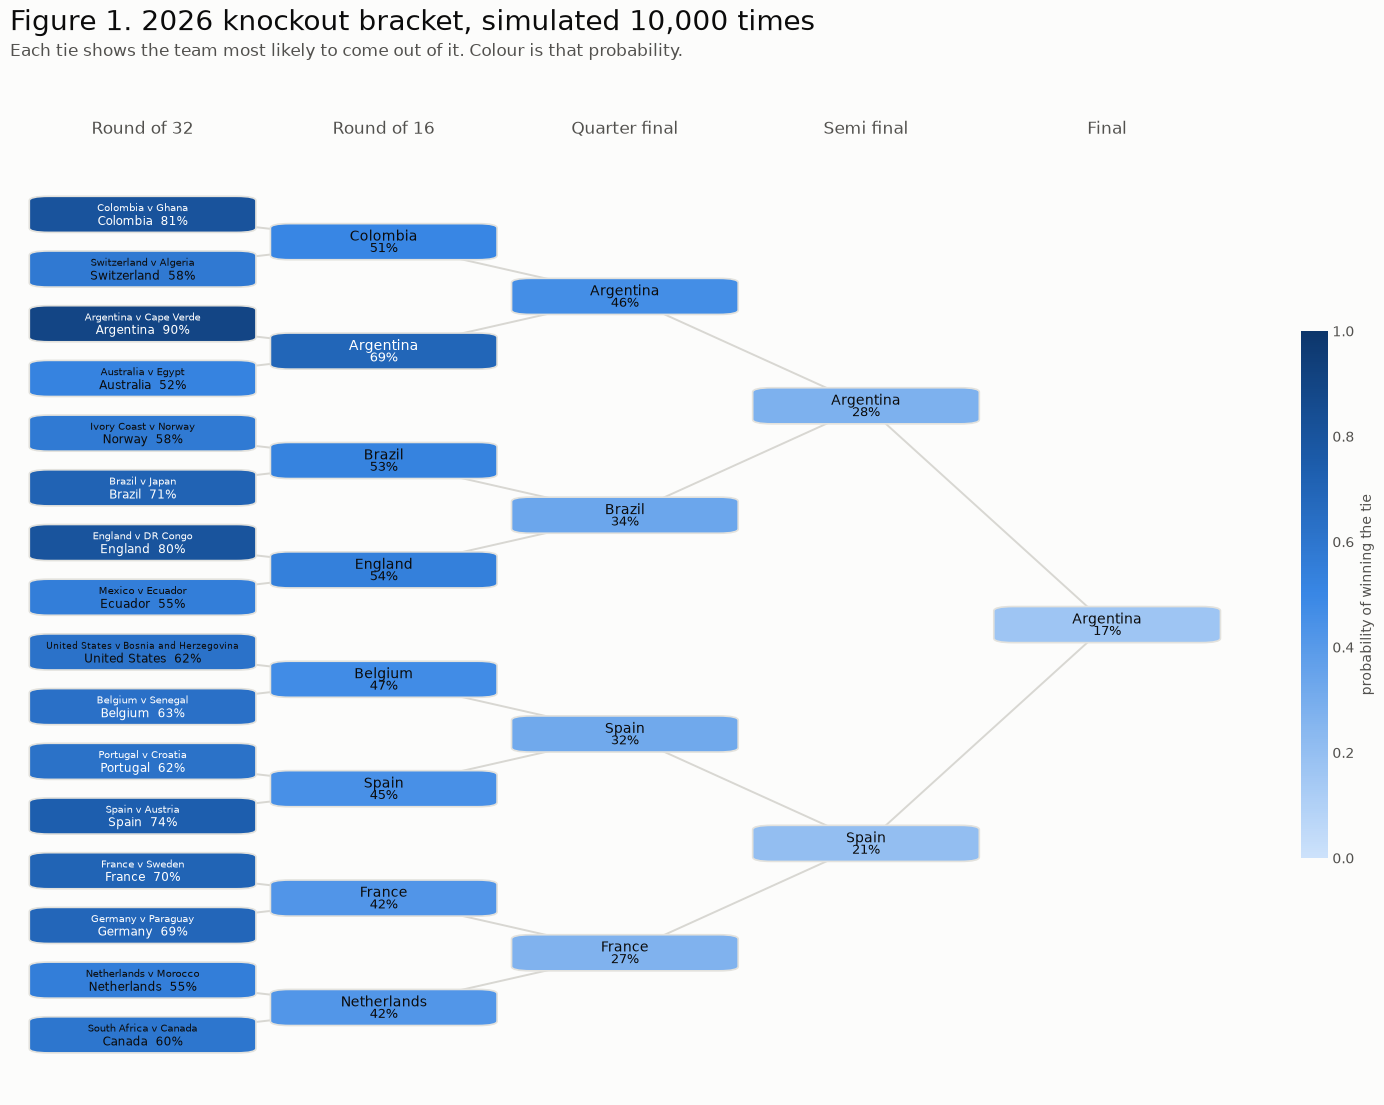

In [24]:
fig, ax = frame("Figure 1. 2026 knockout bracket, simulated 10,000 times",
                "Each tie shows the team most likely to come out of it. Colour is that probability.")

for node, (x, y) in pos.items():
    favourite, chance = odds.nodes[node].index[0], odds.nodes[node].iloc[0]
    box(ax, x, y, facecolor=BLUES(chance))
    ink = "#ffffff" if chance > 0.62 else INK
    if graph.nodes[node]["round"] == "R32":
        pairing = " v ".join(graph.nodes[node]["teams"])
        ax.text(x, y + 0.11, pairing, ha="center", va="center", color=ink,
                fontsize=7.4 if len(pairing) < 30 else 6.3)
        ax.text(x, y - 0.13, f"{favourite}  {chance:.0%}", ha="center", va="center", fontsize=8.6, color=ink)
    else:
        ax.text(x, y + 0.09, favourite, ha="center", va="center", fontsize=10, color=ink)
        ax.text(x, y - 0.13, f"{chance:.0%}", ha="center", va="center", fontsize=9, color=ink)

bar = fig.colorbar(plt.cm.ScalarMappable(cmap=BLUES), ax=ax, fraction=0.02, pad=0.01)
bar.set_label("probability of winning the tie", color=MUTED, fontsize=10)
bar.outline.set_visible(False); bar.ax.tick_params(colors=MUTED, length=0)
plt.show()

### Against what actually happened

The forecast above made no use of the result. This is the same tree with the tournament
filled in, shaded by how close the model got on each tie.

Four states rather than right and wrong. A tie that finished level went to penalties, which
the model treats as a coin flip by construction, so losing one is not a modelling error and
should not be scored as one. Separating them changes the honest reading from 24 of 31 to
**24 of 27 non shootout ties**.

`EXACT` uses the status palette's good colour rather than a darker blue, so exact scorelines
read as a different kind of thing rather than as more of the same.

In [25]:
from matplotlib.lines import Line2D

EXACT, OUTCOME, COIN, MISS, FAINT = "#0ca30c", "#2a78d6", "#ffffff", "#f4f3f0", "#a8a7a1"
happened = model.actual_bracket(final_test)
champion = happened["Final-0"][4]
route = {node for node, row in happened.items() if row[4] == champion}

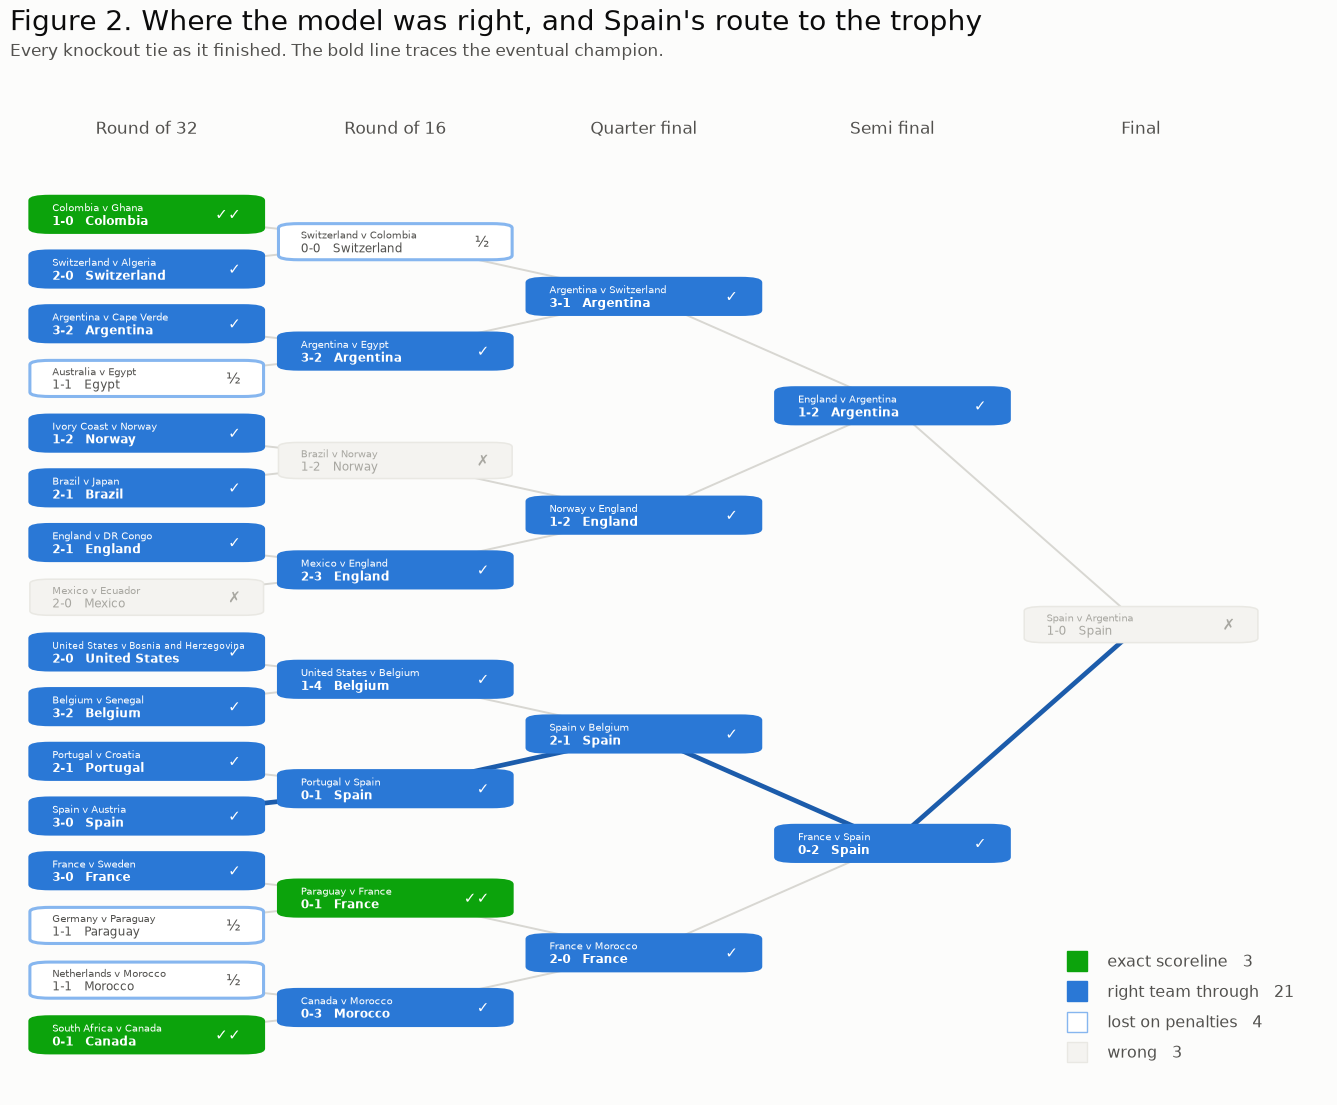

In [26]:
fig, ax = frame(f"Figure 2. Where the model was right, and {champion}'s route to the trophy",
                "Every knockout tie as it finished. The bold line traces the eventual champion.")
nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="#1c5cab", width=3.4, arrows=False, node_size=0,
                       edgelist=[e for e in graph.edges if e[0] in route and e[1] in route])

counts = {"exact": 0, "outcome": 0, "coin": 0, "miss": 0}
for node, (x, y) in pos.items():
    home, away, home_goals, away_goals, winner = happened[node]
    actual = f"{home_goals}-{away_goals}"
    modal = model.likely_scores(current, home, away, n=1).index[0]
    picked = home if model.advance_probs(current, home, away)[0] > 0.5 else away

    if modal == actual:
        fill, edge, ink, mark, level = EXACT, EXACT, "#ffffff", "✓✓", "exact"
    elif picked == winner:
        fill, edge, ink, mark, level = OUTCOME, OUTCOME, "#ffffff", "✓", "outcome"
    elif home_goals == away_goals:
        fill, edge, ink, mark, level = COIN, "#86b6ef", MUTED, "½", "coin"
    else:
        fill, edge, ink, mark, level = MISS, "#e9e8e3", FAINT, "✗", "miss"
    counts[level] += 1

    box(ax, x, y, facecolor=fill, edgecolor=edge, linewidth=2.2 if level != "miss" else 1.1)
    pairing = f"{home} v {away}"
    ax.text(x - 0.38, y + 0.11, pairing, ha="left", va="center", zorder=4, color=ink,
            fontsize=7.2 if len(pairing) < 30 else 6.2)
    ax.text(x - 0.38, y - 0.13, f"{actual}   {winner}", ha="left", va="center", zorder=4,
            fontsize=8.6, color=ink, weight="bold" if level in ("exact", "outcome") else "normal")
    ax.text(x + 0.38, y - 0.02, mark, ha="right", va="center", fontsize=11, color=ink, zorder=4)

swatch = lambda face, edge, label: Line2D([], [], marker="s", linestyle="none", markersize=14,
                                          markerfacecolor=face, markeredgecolor=edge, label=label)
ax.legend(handles=[swatch(EXACT, EXACT, f"exact scoreline   {counts['exact']}"),
                   swatch(OUTCOME, OUTCOME, f"right team through   {counts['outcome']}"),
                   swatch(COIN, "#86b6ef", f"lost on penalties   {counts['coin']}"),
                   swatch(MISS, "#e9e8e3", f"wrong   {counts['miss']}")],
          loc="lower right", frameon=False, fontsize=11.5, labelcolor=MUTED,
          handletextpad=0.9, borderpad=1.6, labelspacing=0.9)
plt.show()

## Simulating the whole tournament

Everything above starts the simulation from the real round of 32, so every number in it is
conditional on the group stage having gone exactly as it did. Argentina's chances are really
"given they topped their group and landed in that half of the draw". A team that went out in
the groups has a probability of zero, which is true after the fact and useless before it.

This runs the tournament from nothing. Seventy two group matches, standings on points then
goal difference then goals scored, the eight best third placed teams, and then the knockout.

Three pieces of structure are needed and none of them is guesswork. The groups themselves
fall out of the fixtures, since within the group stage each team plays exactly the three
others in its group, so the match graph splits into twelve components of four. The round of
32 template, which group positions meet where, is read off the real bracket. And which third
placed team each group winner faces comes from FIFA's published table, cached in
`data/third_place_allocation.csv`, because it depends on which eight groups the qualifying
thirds came from and there are 495 combinations of that.

The one place FIFA's rules are not followed exactly is deep group ties. Points, goal
difference and goals scored are implemented; head to head, fair play and drawing lots are
replaced by a random jitter.

In [27]:
unconditional = model.simulate_tournament(final_test, current, graph, runs=10_000)

table(unconditional.reach.head(12),
      "Table 19. Probability of reaching each round, whole tournaments simulated 10,000 times from the group stage.")

probability of reaching,R32,R16,QF,SF,Final,Winner
team,,,,,,
Brazil,0.990,0.709,0.506,0.337,0.207,0.126
Spain,0.988,0.671,0.453,0.324,0.207,0.125
Argentina,0.981,0.624,0.446,0.298,0.182,0.112
England,0.976,0.662,0.439,0.261,0.157,0.089
France,0.950,0.639,0.392,0.242,0.129,0.073
Portugal,0.945,0.648,0.405,0.236,0.131,0.070
Belgium,0.962,0.675,0.424,0.213,0.113,0.051
Colombia,0.922,0.588,0.340,0.190,0.102,0.048
Germany,0.984,0.643,0.348,0.199,0.101,0.047


The columns still sum to the places each round holds, 32 now that the group stage is in,
which is the same free correctness check as before.

Setting the two side by side shows what conditioning on the real group stage was doing.

In [28]:
table(pd.DataFrame({"from the group stage": unconditional.reach.Winner,
                    "from the real round of 32": odds.reach.Winner}).fillna(0)
        .nlargest(12, "from the group stage").rename_axis(index="team"),
      "Table 20. Probability of winning the tournament, simulated from the group stage against "
      "simulated from the real round of 32.")

,from the group stage,from the real round of 32
team,,
Brazil,0.126,0.121
Spain,0.125,0.118
Argentina,0.112,0.166
England,0.089,0.093
France,0.073,0.071
Portugal,0.070,0.059
Belgium,0.051,0.054
Colombia,0.048,0.059
Germany,0.047,0.052


## One more fit: the morning of the final

Everything above holds the model at the day before the tournament, which is the only honest
way to grade a forecast. This last section asks a different question: what would it have
said on 19 July, having watched the whole tournament except the match about to be played?

The cutoff moves to the final itself, so the fit sees all 103 preceding matches, the group
stage, both semi finals and the third place playoff included. Nothing else changes. Spain
and Argentina each arrive with six more matches on their record than the frozen model had.

**This fit is used for one thing only: the Spain against Argentina forecast below.** It is
not the model, and nothing else in the notebook reads it. It has seen almost the entire
tournament, so its ratings are not comparable with anything above and would flatter it if
scored on anything it was trained on.

A demonstration rather than a test. The final is genuinely held out, so the prediction is out
of sample, but one match proves nothing either way.

In [29]:
eve = model.fit(df, model.FINAL_2026, best, dixon_coles=True)
seen, _ = model.split(df, model.FINAL_2026)

print(f"trained on {len(seen)} matches, up to {seen.date.max().date()}")
print(f"rho {eve.rho:.4f}, against {current.rho:.4f} before the tournament")

trained on 23932 matches, up to 2026-07-18
rho -0.0176, against -0.0168 before the tournament


The final was Spain against Argentina at East Rutherford, on neutral ground, and finished
1-0 to Spain after extra time.

The scoreline table below takes the six most likely results under each fit and shows both
probabilities for every scoreline in either list, so the two columns are always comparable.

In [30]:
forecasts = pd.DataFrame(
    {"before the tournament": model.match_probs(current, "Spain", "Argentina"),
     "morning of the final": model.match_probs(eve, "Spain", "Argentina")},
    index=["Spain win", "draw", "Argentina win"]).rename_axis(index="outcome")

table(forecasts, "Table 21. The final, forecast before the tournament and on the morning of "
                 "the match. It finished 1-0 to Spain after extra time.")

,before the tournament,morning of the final
outcome,,
Spain win,0.335,0.366
draw,0.306,0.304
Argentina win,0.359,0.330


In [31]:
before = model.likely_scores(current, "Spain", "Argentina", n=100)
after = model.likely_scores(eve, "Spain", "Argentina", n=100)
shortlist = before.head(6).index.union(after.head(6).index)

table(pd.DataFrame({"before": before[shortlist], "final morning": after[shortlist]})
        .sort_values("final morning", ascending=False).rename_axis(index="scoreline"),
      "Table 22. Most likely scorelines for the final under both fits, showing every scoreline "
      "in either top six.")

,before,final morning
scoreline,,
1-1,0.137,0.137
1-0,0.125,0.131
0-0,0.128,0.125
0-1,0.131,0.122
2-1,0.069,0.073
2-0,0.065,0.072
1-2,0.072,0.068
0-2,0.071,0.063
